In [263]:
'''
Generation of Ehrenfest data for given initial condition and timestamps
'''
import os
import sys

#sys.path.append(os.path.join(".", "QFPE"))


import expectations as expect
import Hamiltonians as Hams
import params

import numpy as np
import pickle
import sympy as sp

def main():
    t_initial, t_final = (0,40)
    num_points = 201
    sp.init_printing()

    x_0, p_0, xp_px_0, xx_0, pp_0 = sp.symbols('<x>_0 <p>_0 <xp+px>_0 <x^2>_0 <p^2>_0' , constant=True)
    x, p, xp_px, xx, pp = sp.symbols('x p xp_px xx pp', cls=sp.Function)
    D_pp, D_px, D_xx = sp.symbols('D_pp D_px D_xx', constant=True, real=True)
    A = sp.symbols('A', constant=True, imaginary=True)
    t = sp.symbols('t')
    m_s, m, w, w_c, hbar, T, gamma = sp.symbols('m_es m w w_c hbar T gamma', constant=True, positive=True)
    CL_subs = {
            A: - sp.I*gamma/hbar,
            D_px: 0,
            D_pp:-2*m*gamma*T/hbar**2,
            D_xx:0,
            m_s:m
            }
    def make_params(params):
        '''
        Converts keys of params dict from string to corresponding sympy symbol
        '''
        new_params = {}
        conv_dict = {
                "T": T,
                "gamma":gamma,
                "m":m,
                "w":w,
                "hbar":hbar
                }
        for var_name in params:
            try:
                new_params[conv_dict[var_name]] = params[var_name]
            except KeyError as e:
                print(e)
        return new_params

    params_I = make_params(params.params_sp["I"])

    A_eqs = sp.Matrix(
            [
                [0, 1/m_s, 0, 0, 0],
                [-m*w**2, -2*sp.I*A*hbar, 0, 0, 0],
                [0, 0, 0, 0, 1/m_s],
                [0, 0, 0, -4*sp.I*A*hbar, -m*w**2],
                [0, 0, -2*m*w**2, 2/m_s, -2*sp.I*A*hbar]
                ]
            )


    eigen_data = A_eqs.eigenvects()
    for i in range(len(eigen_data)):
        print(eigen_data[i][0], "is eigenvalue")
        print(eigen_data[i][1], "is multiplicity")
        print(eigen_data[i][2], "are the eigenvectors")

    
    inhom_vec = sp.Matrix(
            [
                [0, 0, -2*hbar**2*D_xx, -2*hbar**2*D_pp, 2*hbar**2*D_px]
                ]
            )
    inhom_vec = inhom_vec.T
    print(inhom_vec, "is inhom_vec")
    x_inhom = A_eqs.solve(-inhom_vec)
    print(x_inhom, "is x_inhom")

    pp_0_exact = hbar/(2*m*w) * (1 - sp.exp(-2*hbar*w/T))/(1-sp.exp(-hbar*w/T))**2
    x_vec_0_exact = {
            x_0:2,
            p_0:0,
            xx_0 : pp_0_exact + 4,
            pp_0 : pp_0_exact,
            xp_px_0:0,
            }
   # x_vec_0 = sp.Matrix(
   #         [
   #             [2, 0, pp_0_exact + 4, pp_0_exact, 0 ]
   #         ]
   #         )
    x_vec_0 = sp.Matrix(
            [
                [x_0, p_0, xx_0, pp_0, xp_px_0]
                ]
            )    
    x_vec_0 = x_vec_0.T
    x_diff = x_vec_0 - x_inhom
    c_eqs = sp.Matrix( 5, 5, lambda i,j: eigen_data[j][0] * eigen_data[j][2][0][i])
    print(c_eqs)
    #c_eq_small = c_eqs[:2,3:5]
    c_eq_small = c_eqs[2:,:3]
    c_eq_small = c_eq_small.subs(CL_subs)
    x_diff = x_diff.subs(CL_subs)
    #print(c_eq_small)
    #print(type(c_eq_small))
    #print(type(x_diff))
    #print(type(x_diff[:2]))
    #c_sol = c_eq_small.solve(sp.Matrix([x_diff[:2]]).T)
    c_sol = c_eq_small.solve(sp.Matrix([x_diff[2:]]).T)
    #c_sol = c_sol.subs(x_vec_0_exact)
    print(c_sol, "is c_sol generally")
    #c_sol = c_sol.subs(CL_subs)
    #c_sol= c_sol.subs(params_I)
    c_sol.simplify()
    #x_inhom = x_inhom.subs(CL_subs) #.subs(params_I)
    print(c_sol, "is c_sol")
    # x_p_sol = (c_sol[0]*eigen_data[3][0] * sp.exp(eigen_data[3][0]*t) * eigen_data[3][2][0]
    #         +c_sol[1]*eigen_data[4][0] * sp.exp(eigen_data[4][0]*t) * eigen_data[4][2][0]
    #         + x_inhom
    #         )
    x_p_sol = (c_sol[0]*eigen_data[0][0] * sp.exp(eigen_data[0][0]*t) * eigen_data[0][2][0]
            +c_sol[1]*eigen_data[1][0] * sp.exp(eigen_data[1][0]*t) * eigen_data[1][2][0]
               +c_sol[2]*eigen_data[2][0]*sp.exp(eigen_data[2][0]*t) * eigen_data[2][2][0]
            + x_inhom
            )
    print(x_p_sol)
    x_p_sol = x_p_sol.subs(CL_subs)#.subs(params_I)
    x_p_sol.simplify()
    print(x_p_sol[2], "try to get analytical solution from here")
    return (x_p_sol[2], params_I)
    #print(eigen_data[3][0].subs(CL_subs),"\n", eigen_data[4][0].subs(CL_subs))




In [243]:
print(sys.path)

['C:\\Users\\Taner\\Desktop\\QFPE\\QFPE', 'C:\\Users\\Taner\\anaconda3\\python311.zip', 'C:\\Users\\Taner\\anaconda3\\DLLs', 'C:\\Users\\Taner\\anaconda3\\Lib', 'C:\\Users\\Taner\\anaconda3', '', 'C:\\Users\\Taner\\anaconda3\\Lib\\site-packages', 'C:\\Users\\Taner\\anaconda3\\Lib\\site-packages\\win32', 'C:\\Users\\Taner\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\Taner\\anaconda3\\Lib\\site-packages\\Pythonwin', '.\\QFPE', '.\\QFPE', '.\\QFPE', '.\\QFPE', '.\\QFPE', '.\\QFPE', '.\\QFPE', '.\\QFPE']


In [265]:
res, params_I = main()

'w_c'
'n'
-2*I*A*hbar is eigenvalue
1 is multiplicity
[Matrix([
[                  0],
[                  0],
[  I/(2*A*hbar*m_es)],
[I*m*w**2/(2*A*hbar)],
[                  1]])] are the eigenvectors
-2*I*A*hbar - 2*sqrt(-A**2*hbar**2*m_es - m*w**2)/sqrt(m_es) is eigenvalue
1 is multiplicity
[Matrix([
[                                                                                             0],
[                                                                                             0],
[-I*A*hbar/(m*w**2) - (-2*I*A*hbar - 2*sqrt(-A**2*hbar**2*m_es - m*w**2)/sqrt(m_es))/(4*m*w**2)],
[                         m_es*(-2*I*A*hbar - 2*sqrt(-A**2*hbar**2*m_es - m*w**2)/sqrt(m_es))/4],
[                                                                                             1]])] are the eigenvectors
-2*I*A*hbar + 2*sqrt(-A**2*hbar**2*m_es - m*w**2)/sqrt(m_es) is eigenvalue
1 is multiplicity
[Matrix([
[                                                                              

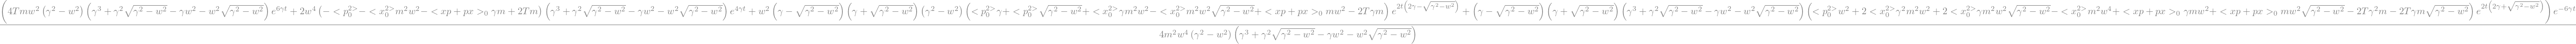

In [271]:
res

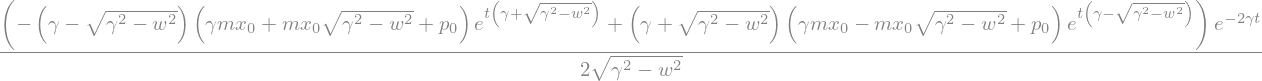

In [203]:
res

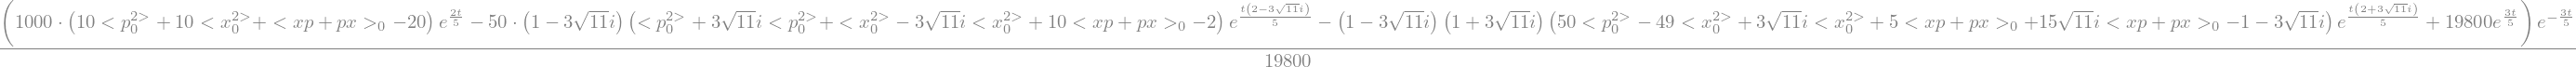

In [275]:
res.subs(params_I).simplify()

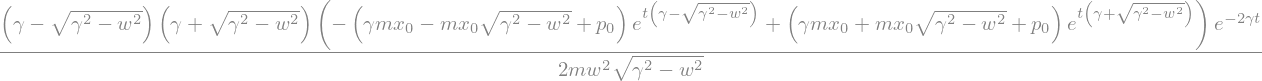

In [104]:
res.subs(params.params_sp["I"])

In [180]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt

def x_func(t):
    return  np.exp(-t/10)*(20/3/np.sqrt(11)/1j)*((3 * np.sqrt(11)/10)*1j*np.cos(3*np.sqrt(11)/10*t) + 1j*0.1*np.sin(3*np.sqrt(11)/10*t))

In [183]:
x_func_1 = x_func(times)

In [191]:
def x_func(t):
    return np.exp(-t/10)*(2*np.cos(3*np.sqrt(11)/10*t) + 2 * np.sqrt(11)/33*np.sin(3*np.sqrt(11)/10*t))


In [193]:
x_func_2 = x_func(times)

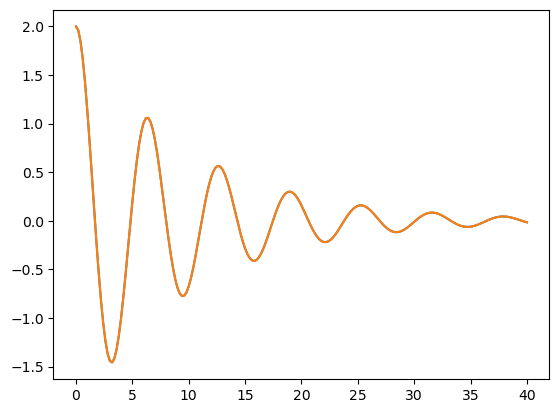

In [195]:
plt.plot(times, x_func_1)
plt.plot(times, x_func_2)

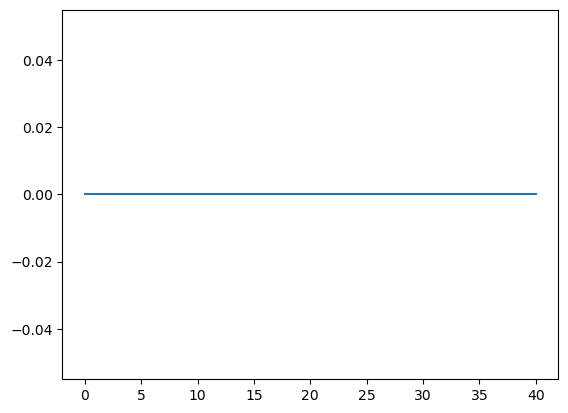

In [94]:
times = np.linspace(0,40,201)
plt.plot(times, np.imag(x_func(times)))